In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten

In [3]:
df = tf.keras.datasets.fashion_mnist

In [ ]:

(X_train, y_train), (X_test, y_test) = df.load_data()

PermissionError: [WinError 5] Access is denied: 'C:\\Users\\DELL\\.keras\\datasets'

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


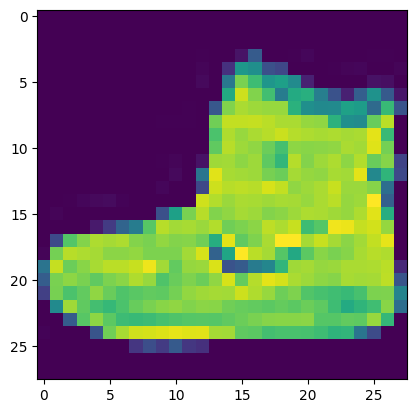

In [ ]:
plt.imshow(X_train[0])
plt.show()

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

In [ ]:
model = Sequential()

In [ ]:
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape = (28,28,1)
    )
)

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [ ]:
model.add(
    Flatten()
)

In [ ]:
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [ ]:
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7401 - loss: 0.7655
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8933 - loss: 0.3025
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9092 - loss: 0.2493
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9240 - loss: 0.2103
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9312 - loss: 0.1874


In [ ]:
loss, accuracy = model.evaluate(X_test,y_test)
print("Accuracy",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9088 - loss: 0.2639
Accuracy 0.910099983215332


In [ ]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
predicted_class = np.argmax(prediction[0])
print(predicted_class)

9


In [ ]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [ ]:
print(class_names[predicted_class])

Ankle boot


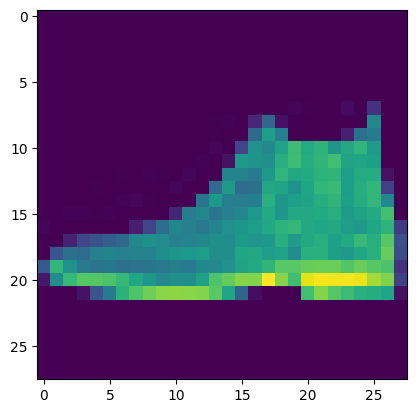

In [ ]:
plt.imshow(X_test[0].reshape(28,28))

plt.show()

In [ ]:
"""# Aim of Practical

To design and implement a **Convolutional Neural Network (CNN)** using the **Fashion MNIST dataset** for classification of fashion clothing images into different categories.

---

# What is Fashion MNIST Dataset?

Fashion MNIST is a dataset of clothing images.

* Total training images = 60,000
* Total testing images = 10,000
* Image size = 28 × 28 pixels
* Grayscale images

The CNN classifies images into 10 categories:

| Label | Category    |
| ----- | ----------- |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

---

# 1. Importing Libraries

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
```

## Explanation

These libraries are required for deep learning and image processing.

| Library    | Purpose                 |
| ---------- | ----------------------- |
| pandas     | Data handling           |
| numpy      | Numerical operations    |
| matplotlib | Display images          |
| tensorflow | Deep learning framework |

---

# 2. Importing CNN Components

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
```

These are the important layers used to build the CNN.

---

# 3. Loading Fashion MNIST Dataset

```python
df = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = df.load_data()
```

---

## Explanation

The Fashion MNIST dataset is loaded from TensorFlow.

### Training Data

```python
X_train
```

Contains training images.

```python
y_train
```

Contains labels for training images.

---

### Testing Data

```python
X_test
```

Contains testing images.

```python
y_test
```

Contains labels for testing images.

---

# 4. Printing Dataset Shape

```python
print(X_train.shape)
print(X_test.shape)
```

---

## Output

```python
(60000, 28, 28)
(10000, 28, 28)
```

---

## Meaning

### Training Dataset

```python
(60000, 28, 28)
```

Means:

* 60,000 images
* each image size = 28 × 28

---

### Testing Dataset

```python
(10000, 28, 28)
```

Means:

* 10,000 testing images
* image size = 28 × 28

---

# 5. Displaying an Image

```python
plt.imshow(X_train[25])
plt.show()
```

---

## Explanation

Displays image at index 25 from training dataset.

```python
X_train[25]
```

means:

* take 25th image

`imshow()` displays image.

---

# 6. Normalization

```python
X_train = X_train/255.0
X_test = X_test/255.0
```

---

## Why Normalization?

Original pixel values range from:

```python
0 to 255
```

After division:

```python
0 to 1
```

---

## Benefits

* Faster training
* Better accuracy
* Stable gradient descent

---

# Example

| Original Pixel | After Normalization |
| -------------- | ------------------- |
| 255            | 1.0                 |
| 128            | 0.50                |

---

# 7. Reshaping Dataset

```python
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)
```

---

# Why Reshape?

CNN requires 4D input format:

```python
(samples,height,width,channels)
```

---

## Meaning

### For Training Data

```python
(60000,28,28,1)
```

| Value | Meaning           |
| ----- | ----------------- |
| 60000 | Number of images  |
| 28    | Height            |
| 28    | Width             |
| 1     | Grayscale channel |

---

# 8. Creating CNN Model

```python
model = Sequential()
```

---

## Explanation

Sequential model means:

* layers are added one after another.

---

# 9. Convolution Layer

```python
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape = (28,28,1)
    )
)
```

---

# What is Convolution Layer?

This layer extracts features from image like:

* edges
* patterns
* curves
* textures

CNN automatically learns these features.

---

# Understanding Parameters

---

## 1. 32 Filters

```python
32
```

CNN learns 32 different feature detectors.

Each filter searches for specific patterns.

---

## 2. Filter Size

```python
(3,3)
```

Means:

* filter size = 3 × 3

Small matrix slides over image.

---

## Convolution Formula

f(x,y)=\sum_{i=0}^{2}\sum_{j=0}^{2}I(x+i,y+j)K(i,j)

Where:

* (I) = image pixels
* (K) = kernel/filter

---

# 3. Activation Function

```python
activation='relu'
```

ReLU function:

f(x)=\max(0,x)

---

## Purpose of ReLU

* removes negative values
* introduces non-linearity
* improves training speed

---

# 4. Input Shape

```python
input_shape=(28,28,1)
```

Specifies:

* image size = 28 × 28
* grayscale channel = 1

---

# 10. Max Pooling Layer

```python
model.add(
    MaxPooling2D(pool_size=(2,2))
)
```

---

# What is Pooling?

Pooling reduces image size while preserving important features.

---

# Example

Suppose:

```python
4 8
2 6
```

MaxPooling selects:

```python
8
```

---

# Benefits

* reduces computation
* reduces overfitting
* speeds up training

---

# 11. Flatten Layer

```python
model.add(
    Flatten()
)
```

---

# Purpose

Converts multidimensional feature maps into a 1D vector.

Before Flatten:

* 2D or 3D matrix

After Flatten:

* single long vector

Required before Dense layers.

---

# 12. Dense Hidden Layer

```python
model.add(
    Dense(
        128,
        activation='relu'
    )
)
```

---

# Explanation

Fully connected neural network layer.

Contains:

* 128 neurons

Learns high-level image patterns.

---

# 13. Output Layer

```python
model.add(
    Dense(
        10,
        activation='softmax'
    )
)
```

---

# Why 10 Neurons?

Because dataset has:

* 10 clothing categories

---

# Softmax Function

Converts outputs into probabilities.

P(y_i)=\frac{e^{z_i}}{\sum_{j=1}^{n}e^{z_j}}

Highest probability becomes predicted class.

---

# 14. Compiling Model

```python
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
```

---

# Optimizer

```python
optimizer='adam'
```

Adam updates weights efficiently.

---

# Loss Function

```python
loss='sparse_categorical_crossentropy'
```

Used for multiclass classification.

Measures prediction error.

---

# Accuracy Metric

```python
metrics=['accuracy']
```

Shows percentage of correct predictions.

---

# 15. Training the Model

```python
model.fit(
    X_train,
    y_train,
    epochs=5
)
```

---

# What Happens During Training?

CNN:

* reads images
* extracts features
* updates weights
* learns patterns

---

# Epoch

```python
epochs=5
```

Means:

* complete dataset passes through network 5 times.

---

# 16. Evaluating Model

```python
loss, accuracy = model.evaluate(X_test,y_test)
```

---

# Purpose

Tests CNN on unseen testing data.

---

# Output

```python
print("Accuracy",accuracy)
```

Example:

```python
Accuracy 0.91
```

Means:

* 91% predictions are correct.

---

# 17. Predicting Classes

```python
prediction = model.predict(X_test)
```

---

# Explanation

CNN predicts probabilities for all test images.

---

# 18. Predicting Specific Image

```python
predicted_class = np.argmax(prediction[25])
```

---

# Explanation

```python
prediction[25]
```

contains probabilities for image at index 25.

Example:

```python
[0.01,0.02,0.80,0.03,...]
```

`argmax()` finds highest probability index.

---

# 19. Class Names

```python
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
```

Maps numeric labels to clothing names.

---

# 20. Printing Predicted Class

```python
print(class_names[predicted_class])
```

Example output:

```python
Bag
```

---

# 21. Displaying Predicted Image

```python
plt.imshow(X_test[25].reshape(28,28))
plt.show()
```

---

# Explanation

Displays test image at index 25.

You can visually compare:

* image
* predicted class

---

# Complete CNN Flow

```text
Input Image
      ↓
Convolution Layer
      ↓
Feature Maps
      ↓
Pooling Layer
      ↓
Reduced Features
      ↓
Flatten Layer
      ↓
Dense Layers
      ↓
Classification Output
```

---

# Why CNN is Used for Images?

CNN automatically learns:

* edges
* shapes
* textures
* object patterns

without manual feature extraction.

---

# Advantages of CNN

* High image classification accuracy
* Automatic feature extraction
* Less preprocessing required
* Efficient for computer vision tasks

---

# Practical Conclusion

This practical successfully implements a Convolutional Neural Network (CNN) using the Fashion MNIST dataset for image classification. The CNN extracts image features using convolution and pooling layers and classifies fashion clothing into 10 categories with high accuracy.
"""